# Amazon-Style E-Commerce Sales Analytics

## 03 — Sales Performance Analysis

### Objective

The objective of this notebook is to perform a focused analysis of e-commerce sales performance.

The analysis examines revenue, order volume, average order value, sales growth, order status, product categories, sales volume, and temporal patterns to identify areas of strong and weak performance.

### Key Business Questions

1. How has sales performance changed over time?
2. Which months and quarters generate the highest sales?
3. How is Average Order Value changing?
4. How do different order statuses affect reported sales?
5. Which categories contribute most to sales?
6. Are high sales volumes associated with high revenue?
7. What proportion of sales comes from high-value orders?
8. Which days of the week perform best?
9. How concentrated is the business revenue?
10. What are the most important sales-performance insights?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (100000, 25)


## 1. Sales Metric Definitions

To avoid ambiguity, sales metrics are defined before analysis.

- Gross Order Value (GOV): Total value of all recorded orders.
- Delivered Order Value: Total value associated with orders marked as Delivered.
- Total Orders: Number of unique orders.
- Units Sold: Total quantity across orders.
- Average Order Value (AOV): Gross Order Value divided by total orders.

Gross Order Value should not automatically be interpreted as realized revenue because the dataset contains returned and cancelled orders.

In [3]:
gross_order_value = df["TotalAmount"].sum()

total_orders = df["OrderID"].nunique()

total_units = df["Quantity"].sum()

average_order_value = (
    gross_order_value / total_orders
)

delivered_order_value = df.loc[
    df["OrderStatus"] == "Delivered",
    "TotalAmount"
].sum()

delivered_orders = (
    df["OrderStatus"] == "Delivered"
).sum()

print(f"Gross Order Value      : ${gross_order_value:,.2f}")
print(f"Total Orders           : {total_orders:,}")
print(f"Total Units            : {total_units:,}")
print(f"Average Order Value    : ${average_order_value:,.2f}")
print(f"Delivered Order Value  : ${delivered_order_value:,.2f}")
print(f"Delivered Orders       : {delivered_orders:,}")

Gross Order Value      : $91,825,647.92
Total Orders           : 100,000
Total Units            : 300,140
Average Order Value    : $918.26
Delivered Order Value  : $68,372,677.10
Delivered Orders       : 74,628


## 2. Overall Sales Performance

This section establishes the overall scale of the business using order value, order volume, units sold, and average order value.

In [4]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Gross Order Value",
        "Delivered Order Value",
        "Total Orders",
        "Delivered Orders",
        "Total Units",
        "Average Order Value"
    ],
    "Value": [
        gross_order_value,
        delivered_order_value,
        total_orders,
        delivered_orders,
        total_units,
        average_order_value
    ]
})

sales_summary

,Metric,Value
0,Gross Order Value,9.182565e+07
1,Delivered Order Value,6.837268e+07
2,Total Orders,1.000000e+05
3,Delivered Orders,7.462800e+04
4,Total Units,3.001400e+05
5,Average Order Value,9.182565e+02


In [5]:
delivered_order_percentage = (
    delivered_orders / total_orders * 100
)

print(
    f"Delivered Order Percentage: "
    f"{delivered_order_percentage:.2f}%"
)

Delivered Order Percentage: 74.63%


## 3. Monthly Sales Growth

Monthly sales performance is analyzed using Gross Order Value, order volume, and Average Order Value.

Month-over-month growth is calculated to identify periods of acceleration and decline.

In [6]:
monthly_performance = (
    df.groupby("YearMonth")
      .agg(
          Gross_Order_Value=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .reset_index()
)

monthly_performance["AOV"] = (
    monthly_performance["Gross_Order_Value"] /
    monthly_performance["Orders"]
)

monthly_performance["Revenue_Growth_%"] = (
    monthly_performance["Gross_Order_Value"]
    .pct_change() * 100
)

monthly_performance["Order_Growth_%"] = (
    monthly_performance["Orders"]
    .pct_change() * 100
)

monthly_performance.head()

,YearMonth,Gross_Order_Value,Orders,Units,AOV,Revenue_Growth_%,Order_Growth_%
0,2020-01,1637069.40,1730,5225,946.282890,NaN,NaN
1,2020-02,1339388.21,1490,4343,898.918262,-18.183786,-13.872832
2,2020-03,1587125.66,1685,5050,941.914338,18.496314,13.087248
3,2020-04,1588347.29,1692,5156,938.739533,0.076971,0.415430
4,2020-05,1533834.17,1672,5061,917.364934,-3.432066,-1.182033


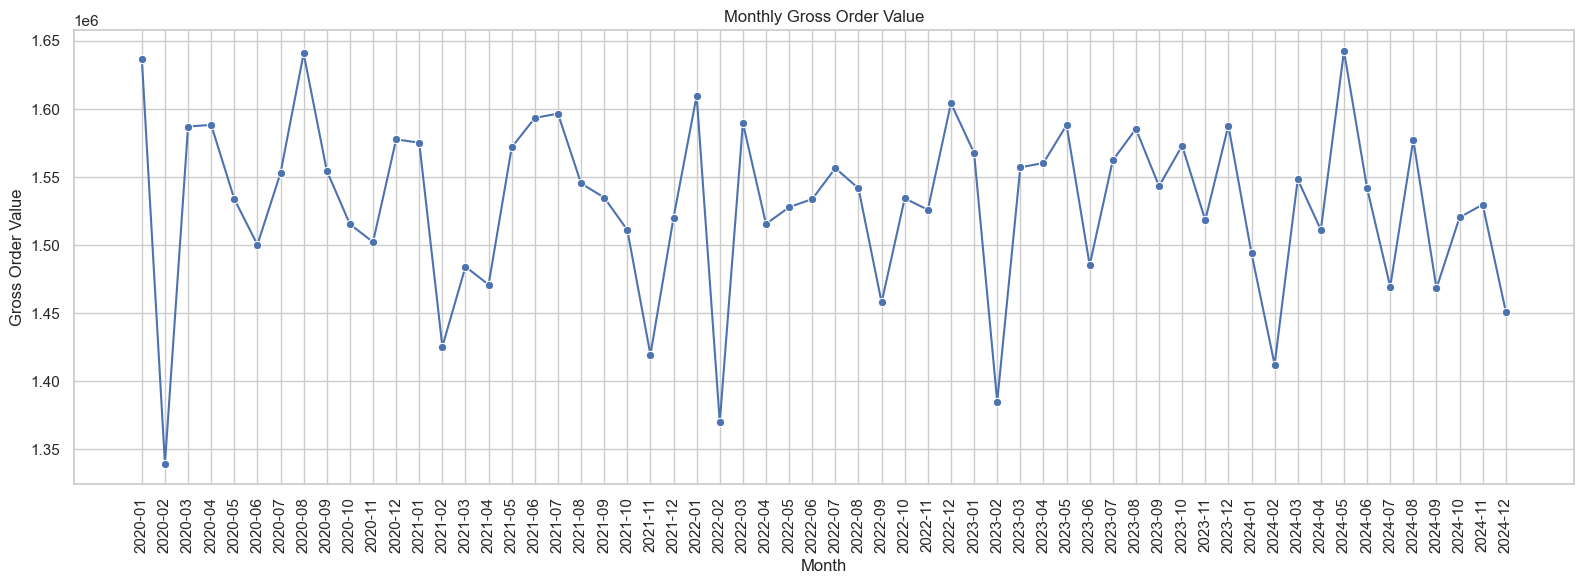

In [7]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_performance,
    x="YearMonth",
    y="Gross_Order_Value",
    marker="o"
)

plt.title("Monthly Gross Order Value")
plt.xlabel("Month")
plt.ylabel("Gross Order Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

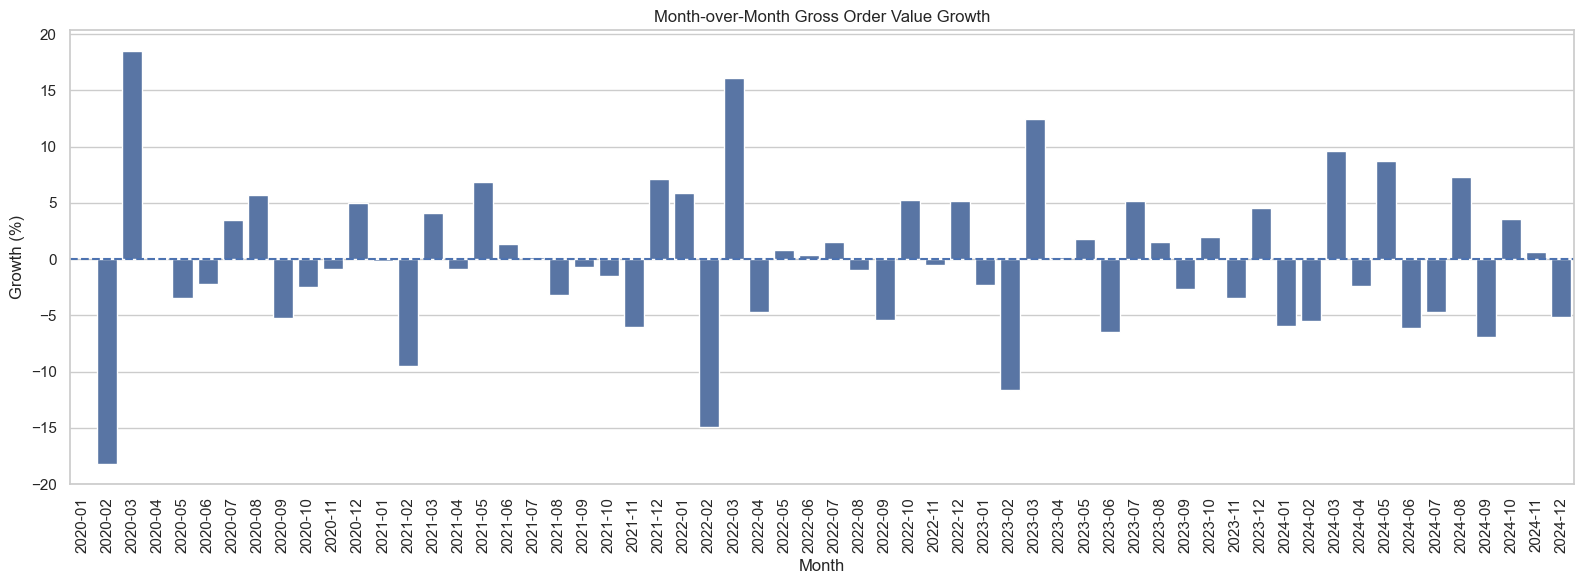

In [8]:
plt.figure(figsize=(16, 6))

sns.barplot(
    data=monthly_performance,
    x="YearMonth",
    y="Revenue_Growth_%"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Month-over-Month Gross Order Value Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [9]:
best_month = monthly_performance.loc[
    monthly_performance["Gross_Order_Value"].idxmax()
]

worst_month = monthly_performance.loc[
    monthly_performance["Gross_Order_Value"].idxmin()
]

print(
    f"Highest sales month: {best_month['YearMonth']} "
    f"(${best_month['Gross_Order_Value']:,.2f})"
)

print(
    f"Lowest sales month: {worst_month['YearMonth']} "
    f"(${worst_month['Gross_Order_Value']:,.2f})"
)

Highest sales month: 2024-05 ($1,642,609.94)
Lowest sales month: 2020-02 ($1,339,388.21)


In [10]:
highest_growth = monthly_performance.loc[
    monthly_performance["Revenue_Growth_%"].idxmax()
]

lowest_growth = monthly_performance.loc[
    monthly_performance["Revenue_Growth_%"].idxmin()
]

print(
    f"Highest MoM growth: {highest_growth['YearMonth']} "
    f"({highest_growth['Revenue_Growth_%']:.2f}%)"
)

print(
    f"Lowest MoM growth: {lowest_growth['YearMonth']} "
    f"({lowest_growth['Revenue_Growth_%']:.2f}%)"
)

Highest MoM growth: 2020-03 (18.50%)
Lowest MoM growth: 2020-02 (-18.18%)


## 4. Average Order Value Analysis

Average Order Value (AOV) measures the average monetary value of an order.

AOV is analyzed over time to determine whether changes in sales are associated with changes in the value of individual orders.

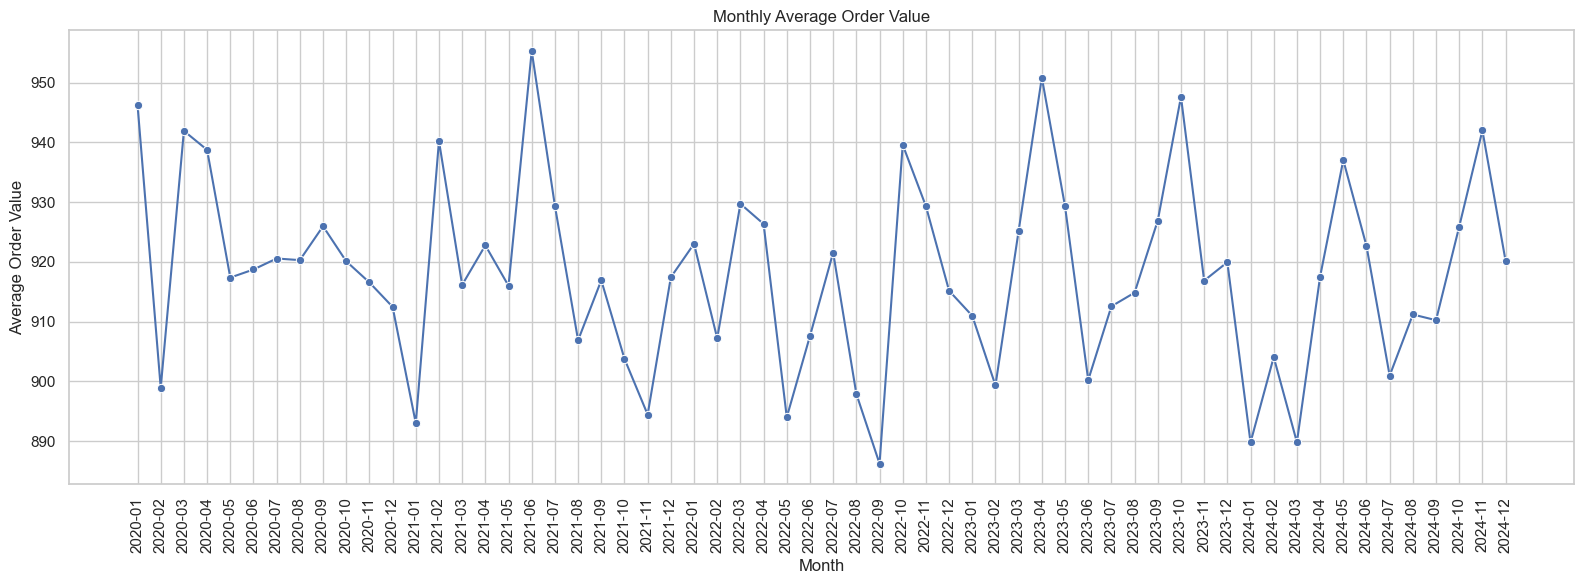

In [11]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_performance,
    x="YearMonth",
    y="AOV",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [12]:
highest_aov_month = monthly_performance.loc[
    monthly_performance["AOV"].idxmax()
]

lowest_aov_month = monthly_performance.loc[
    monthly_performance["AOV"].idxmin()
]

print(
    f"Highest AOV month: {highest_aov_month['YearMonth']} "
    f"(${highest_aov_month['AOV']:,.2f})"
)

print(
    f"Lowest AOV month: {lowest_aov_month['YearMonth']} "
    f"(${lowest_aov_month['AOV']:,.2f})"
)

Highest AOV month: 2021-06 ($955.27)
Lowest AOV month: 2022-09 ($886.24)


## 5. Sales Performance by Order Status

Order status is analyzed to understand how order value is distributed across Delivered, Shipped, Pending, Returned, and Cancelled orders.

This analysis does not assume that cancelled or returned order value represents realized revenue.

In [13]:
status_sales = (
    df.groupby("OrderStatus")
      .agg(
          Orders=("OrderID", "nunique"),
          Order_Value=("TotalAmount", "sum"),
          Units=("Quantity", "sum"),
          AOV=("TotalAmount", "mean")
      )
      .sort_values("Order_Value", ascending=False)
)

status_sales

,Orders,Order_Value,Units,AOV
OrderStatus,,,,
Delivered,74628,68372677.10,223759,916.179947
Shipped,15192,14083628.99,45660,927.042456
Pending,4103,3737556.98,12338,910.932727
Cancelled,3028,2851122.39,9242,941.585994
Returned,3049,2780662.46,9141,911.991623


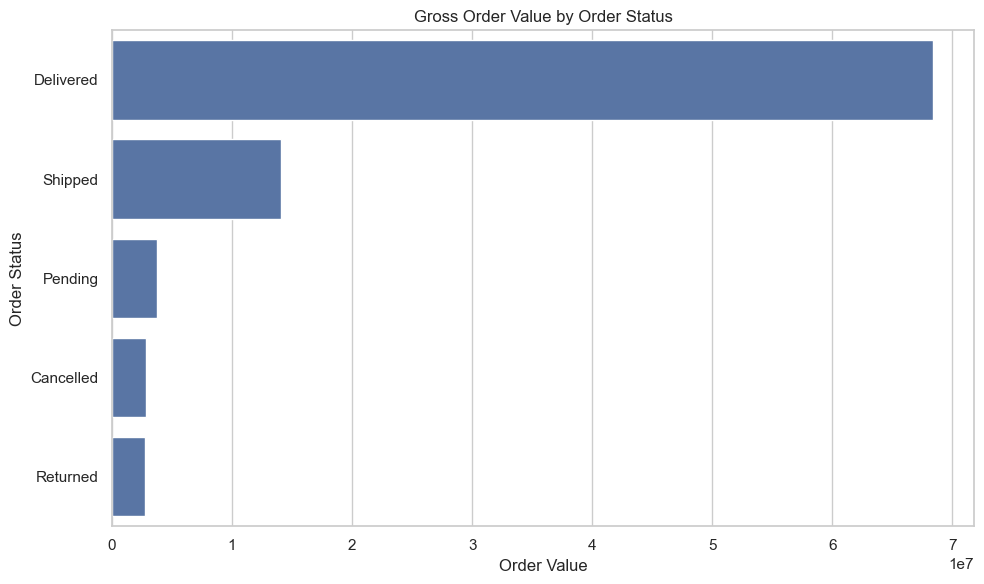

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=status_sales.reset_index(),
    x="Order_Value",
    y="OrderStatus"
)

plt.title("Gross Order Value by Order Status")
plt.xlabel("Order Value")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

In [15]:
status_sales["Order_Share_%"] = (
    status_sales["Orders"] /
    status_sales["Orders"].sum() * 100
)

status_sales

,Orders,Order_Value,Units,AOV,Order_Share_%
OrderStatus,,,,,
Delivered,74628,68372677.10,223759,916.179947,74.628
Shipped,15192,14083628.99,45660,927.042456,15.192
Pending,4103,3737556.98,12338,910.932727,4.103
Cancelled,3028,2851122.39,9242,941.585994,3.028
Returned,3049,2780662.46,9141,911.991623,3.049


## 6. Category Sales Performance

Category-level sales performance is compared across revenue, order volume, units sold, and Average Order Value.

The objective is to identify categories that generate high revenue and categories where sales volume and monetary contribution differ.

In [16]:
category_performance = (
    df.groupby("Category")
      .agg(
          Order_Value=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          AOV=("TotalAmount", "mean"),
          Average_Discount=("Discount", "mean")
      )
)

category_performance["Revenue_Share_%"] = (
    category_performance["Order_Value"] /
    category_performance["Order_Value"].sum() * 100
)

category_performance = (
    category_performance
    .sort_values("Order_Value", ascending=False)
)

category_performance

,Order_Value,Orders,Units,AOV,Average_Discount,Revenue_Share_%
Category,,,,,,
Electronics,15584217.18,16853,50696,924.714720,0.074340,16.971530
Sports & Outdoors,15345571.88,16804,50543,913.209467,0.074000,16.711640
Books,15261837.01,16752,49981,911.045667,0.073896,16.620451
Clothing,15253397.50,16439,49523,927.878673,0.073970,16.611260
Toys & Games,15216684.99,16542,49773,919.881815,0.074066,16.571280
Home & Kitchen,15163939.36,16610,49624,912.940359,0.075084,16.513839


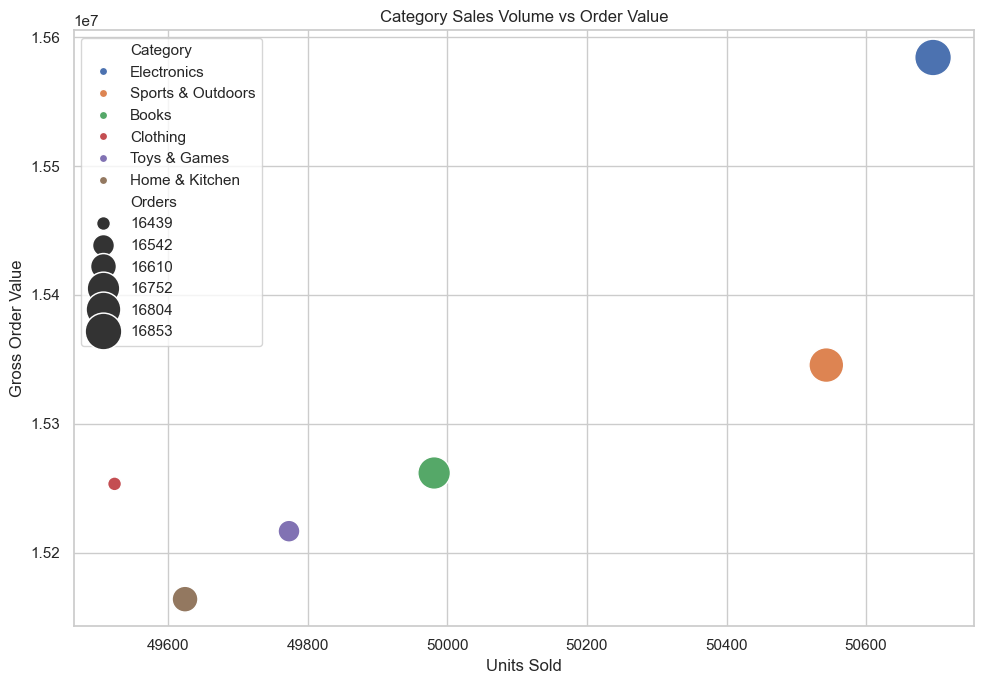

In [17]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=category_performance,
    x="Units",
    y="Order_Value",
    size="Orders",
    hue="Category",
    sizes=(100, 700)
)

plt.title("Category Sales Volume vs Order Value")
plt.xlabel("Units Sold")
plt.ylabel("Gross Order Value")

plt.tight_layout()
plt.show()

## 7. Sales Volume vs Order Value

This analysis examines whether orders containing more units generally have higher monetary value.

In [18]:
quantity_value_correlation = df[
    ["Quantity", "TotalAmount"]
].corr().iloc[0, 1]

print(
    f"Correlation between Quantity and TotalAmount: "
    f"{quantity_value_correlation:.3f}"
)

Correlation between Quantity and TotalAmount: 0.595


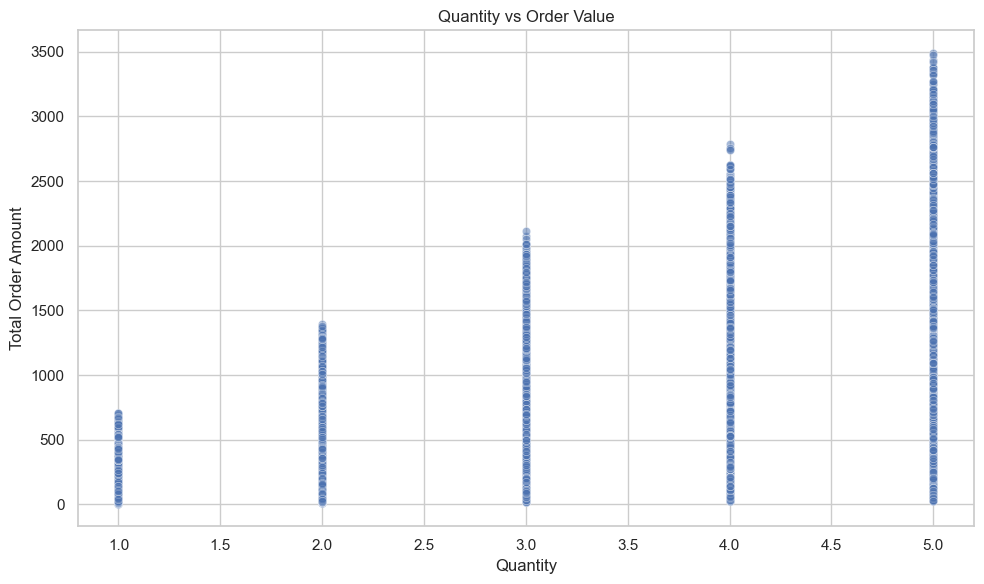

In [19]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="TotalAmount",
    alpha=0.5
)

plt.title("Quantity vs Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Order Amount")

plt.tight_layout()
plt.show()

## 8. Order Value Segmentation

Orders are divided into quartiles based on TotalAmount to understand how order value is distributed across the customer transaction base.

In [20]:
q1 = df["TotalAmount"].quantile(0.25)
q2 = df["TotalAmount"].quantile(0.50)
q3 = df["TotalAmount"].quantile(0.75)

print(f"Q1: ${q1:.2f}")
print(f"Median: ${q2:.2f}")
print(f"Q3: ${q3:.2f}")

Q1: $340.89
Median: $714.32
Q3: $1349.76


In [21]:
df["Order_Value_Segment"] = pd.cut(
    df["TotalAmount"],
    bins=[
        -np.inf,
        q1,
        q2,
        q3,
        np.inf
    ],
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ]
)

In [22]:
order_value_segments = (
    df.groupby(
        "Order_Value_Segment",
        observed=True
    )
    .agg(
        Orders=("OrderID", "nunique"),
        Order_Value=("TotalAmount", "sum"),
        Units=("Quantity", "sum")
    )
)

order_value_segments["Order_Value_Share_%"] = (
    order_value_segments["Order_Value"] /
    order_value_segments["Order_Value"].sum() * 100
)

order_value_segments

,Orders,Order_Value,Units,Order_Value_Share_%
Order_Value_Segment,,,,
Low Value,25001,4482191.72,54069,4.881198
Medium-Low Value,24999,12755288.60,59144,13.890769
Medium-High Value,25000,25282599.02,80894,27.533265
High Value,25000,49305568.58,106033,53.694768


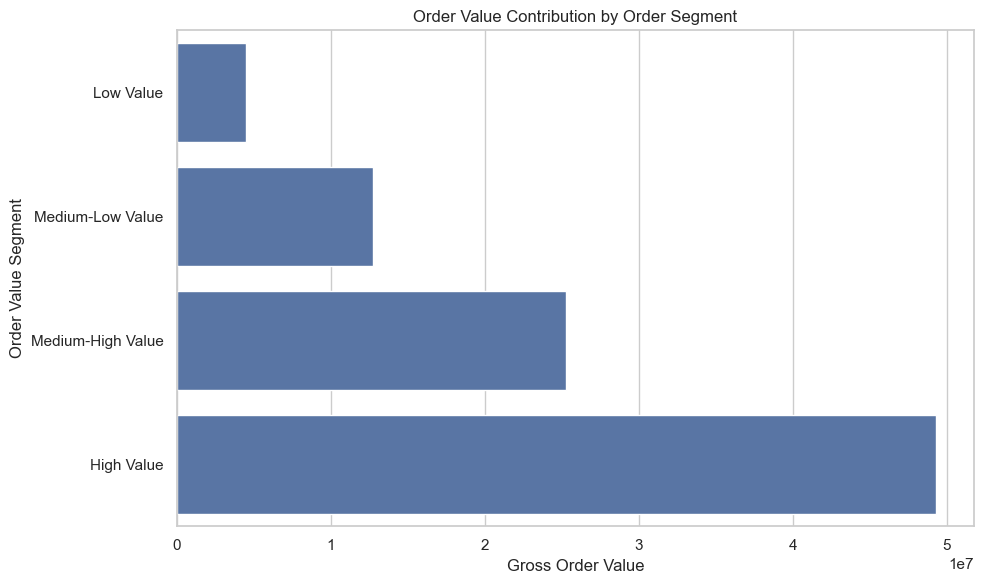

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=order_value_segments.reset_index(),
    x="Order_Value",
    y="Order_Value_Segment"
)

plt.title("Order Value Contribution by Order Segment")
plt.xlabel("Gross Order Value")
plt.ylabel("Order Value Segment")

plt.tight_layout()
plt.show()

## 9. Sales Performance by Day of Week

Daily sales patterns are analyzed to determine whether certain days consistently generate higher order value or order volume.

In [24]:
df["DayOfWeek"] = df["OrderDate"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [25]:
day_performance = (
    df.groupby("DayOfWeek")
      .agg(
          Order_Value=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum"),
          AOV=("TotalAmount", "mean")
      )
      .reindex(day_order)
)

day_performance

,Order_Value,Orders,Units,AOV
DayOfWeek,,,,
Monday,12980069.99,14150,42640,917.319434
Tuesday,13345635.44,14416,43267,925.751626
Wednesday,12976968.96,14225,42423,912.264953
Thursday,13284742.73,14460,43600,918.723564
Friday,13228925.87,14309,42939,924.517847
Saturday,13088027.30,14316,42860,914.223757
Sunday,12921277.63,14124,42411,914.845485


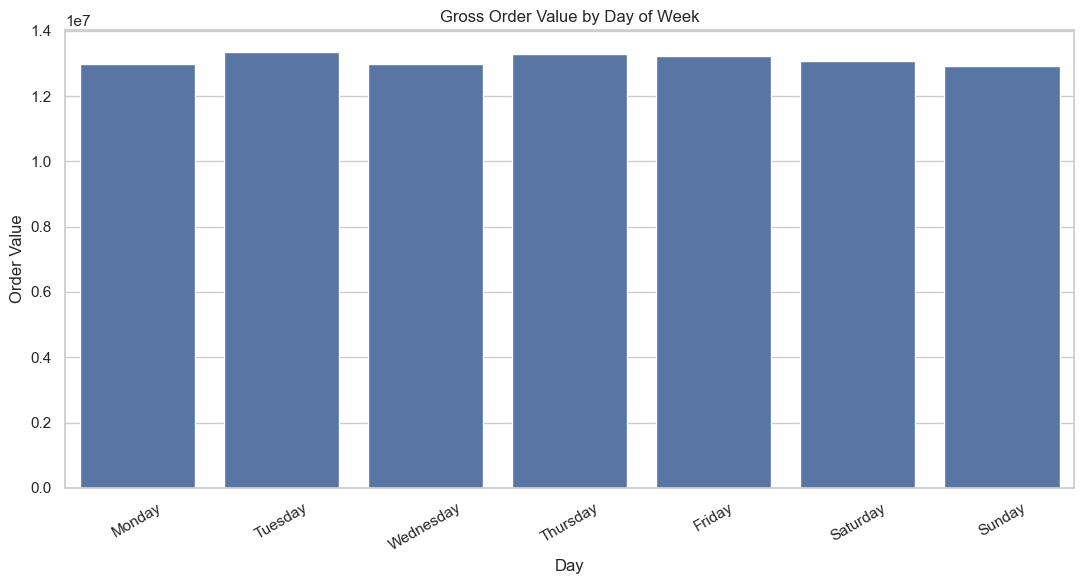

In [26]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=day_performance.reset_index(),
    x="DayOfWeek",
    y="Order_Value"
)

plt.title("Gross Order Value by Day of Week")
plt.xlabel("Day")
plt.ylabel("Order Value")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

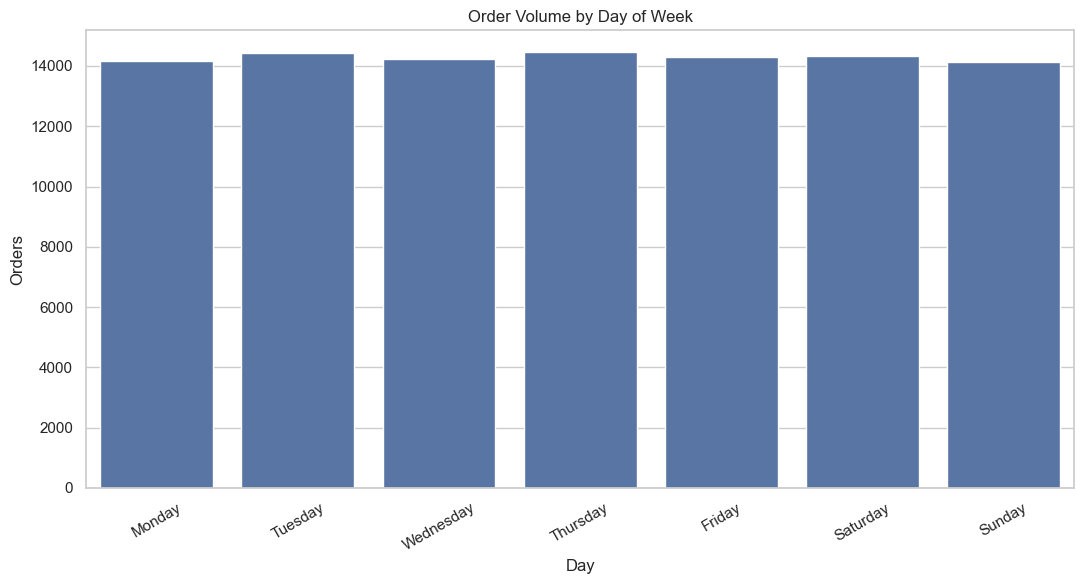

In [27]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=day_performance.reset_index(),
    x="DayOfWeek",
    y="Orders"
)

plt.title("Order Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 10. Quarterly Sales Performance

Quarterly analysis provides a higher-level view of seasonal and periodic sales performance.

In [28]:
quarterly_performance = (
    df.groupby(["Year", "Quarter"])
      .agg(
          Order_Value=("TotalAmount", "sum"),
          Orders=("OrderID", "nunique"),
          Units=("Quantity", "sum")
      )
      .reset_index()
)

quarterly_performance["AOV"] = (
    quarterly_performance["Order_Value"] /
    quarterly_performance["Orders"]
)

quarterly_performance

,Year,Quarter,Order_Value,Orders,Units,AOV
0,2020,1,4563583.27,4905,14618,930.394143
1,2020,2,4622450.75,4997,15100,925.045177
2,2020,3,4748539.08,5149,15523,922.225496
3,2020,4,4595290.92,5015,14967,916.309256
4,2021,1,4484785.11,4900,14673,915.262267
5,2021,2,4636125.35,4978,15008,931.322891
6,2021,3,4676905.00,5096,15199,917.760008
7,2021,4,4450759.35,4916,14761,905.361951
8,2022,1,4569435.51,4964,14884,920.514809
9,2022,2,4577172.31,5035,15002,909.070965


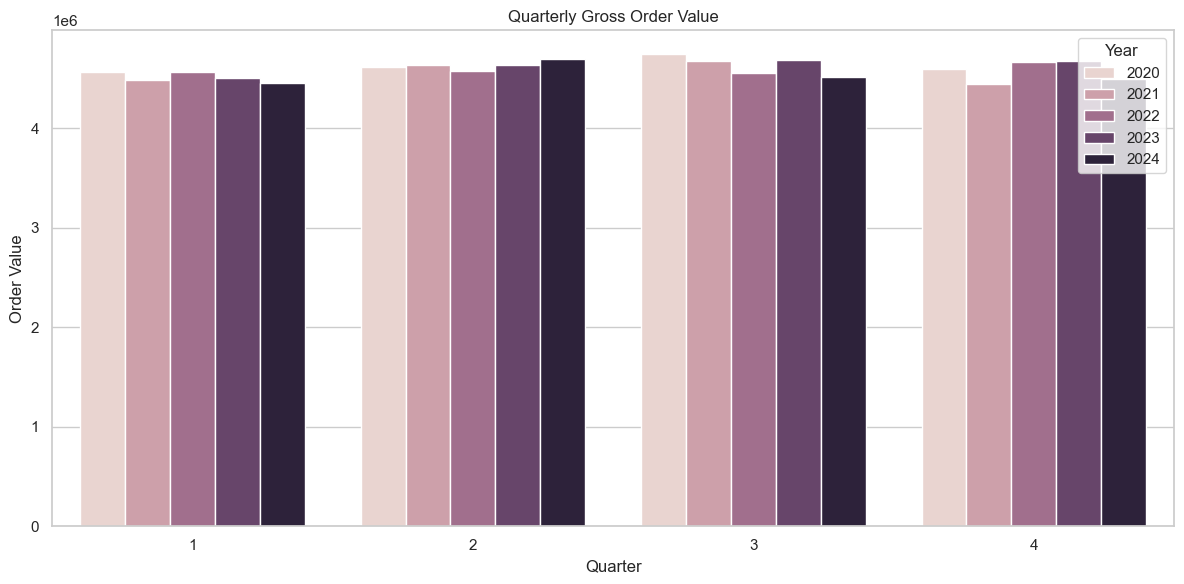

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=quarterly_performance,
    x="Quarter",
    y="Order_Value",
    hue="Year"
)

plt.title("Quarterly Gross Order Value")
plt.xlabel("Quarter")
plt.ylabel("Order Value")

plt.tight_layout()
plt.show()

## 11. Revenue Concentration

Revenue concentration is examined by ranking orders according to TotalAmount and calculating their cumulative contribution to Gross Order Value.

In [30]:
order_values = (
    df[["OrderID", "TotalAmount"]]
    .sort_values(
        "TotalAmount",
        ascending=False
    )
    .copy()
)

order_values["Cumulative_Order_Value"] = (
    order_values["TotalAmount"].cumsum()
)

order_values["Cumulative_Share_%"] = (
    order_values["Cumulative_Order_Value"] /
    order_values["TotalAmount"].sum() * 100
)

order_values["Order_Rank"] = (
    range(1, len(order_values) + 1)
)

order_values["Order_Share_%"] = (
    order_values["Order_Rank"] /
    len(order_values) * 100
)

order_values.head(10)

,OrderID,TotalAmount,Cumulative_Order_Value,Cumulative_Share_%,Order_Rank,Order_Share_%
48442,ORD0048443,3534.98,3534.98,0.003850,1,0.001
81886,ORD0081887,3521.85,7056.83,0.007685,2,0.002
4196,ORD0004197,3514.24,10571.07,0.011512,3,0.003
1929,ORD0001930,3513.65,14084.72,0.015339,4,0.004
58204,ORD0058205,3513.05,17597.77,0.019164,5,0.005
46764,ORD0046765,3511.95,21109.72,0.022989,6,0.006
40146,ORD0040147,3510.23,24619.95,0.026812,7,0.007
20578,ORD0020579,3509.30,28129.25,0.030633,8,0.008
95429,ORD0095430,3499.15,31628.40,0.034444,9,0.009
51547,ORD0051548,3498.13,35126.53,0.038254,10,0.010


In [31]:
orders_for_80_percent = (
    order_values[
        order_values["Cumulative_Share_%"] <= 80
    ]
    .shape[0]
)

percentage_orders_for_80 = (
    orders_for_80_percent /
    len(order_values) * 100
)

print(
    f"Approximately {percentage_orders_for_80:.2f}% "
    f"of orders account for the first 80% of cumulative order value."
)

Approximately 48.46% of orders account for the first 80% of cumulative order value.


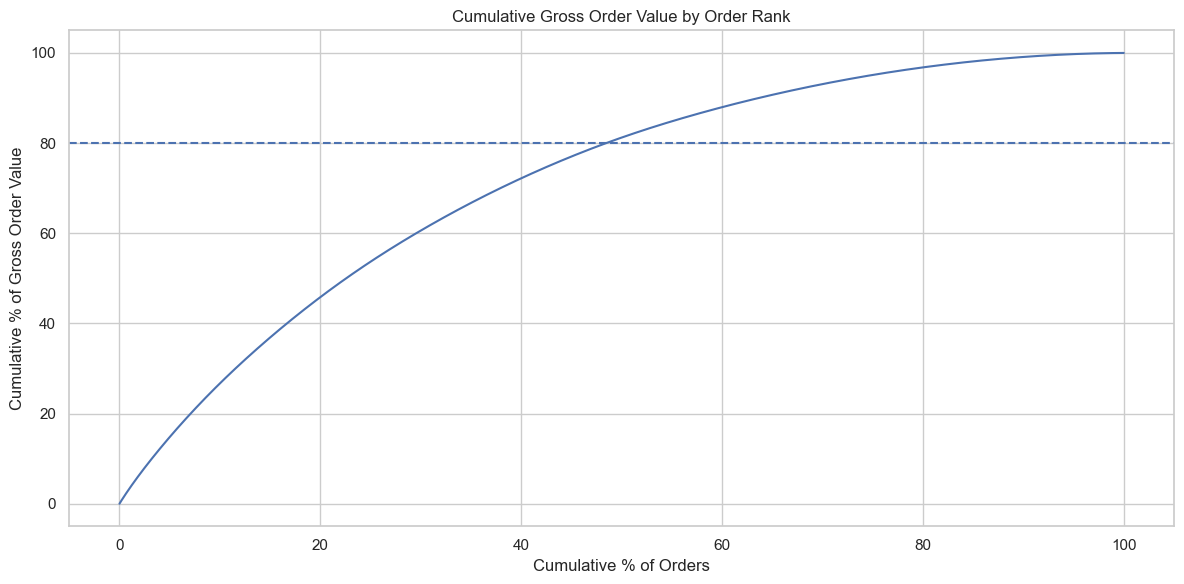

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    order_values["Order_Share_%"],
    order_values["Cumulative_Share_%"]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Cumulative Gross Order Value by Order Rank")
plt.xlabel("Cumulative % of Orders")
plt.ylabel("Cumulative % of Gross Order Value")

plt.tight_layout()
plt.show()

In [33]:
category_performance["Revenue_Rank"] = (
    category_performance["Order_Value"]
    .rank(
        ascending=False,
        method="dense"
    )
)

category_performance["Unit_Rank"] = (
    category_performance["Units"]
    .rank(
        ascending=False,
        method="dense"
    )
)

category_performance

,Order_Value,Orders,Units,AOV,Average_Discount,Revenue_Share_%,Revenue_Rank,Unit_Rank
Category,,,,,,,,
Electronics,15584217.18,16853,50696,924.714720,0.074340,16.971530,1.0,1.0
Sports & Outdoors,15345571.88,16804,50543,913.209467,0.074000,16.711640,2.0,2.0
Books,15261837.01,16752,49981,911.045667,0.073896,16.620451,3.0,3.0
Clothing,15253397.50,16439,49523,927.878673,0.073970,16.611260,4.0,6.0
Toys & Games,15216684.99,16542,49773,919.881815,0.074066,16.571280,5.0,4.0
Home & Kitchen,15163939.36,16610,49624,912.940359,0.075084,16.513839,6.0,5.0


In [34]:
top_revenue_category = category_performance.sort_values(
    "Order_Value",
    ascending=False
).iloc[0]

top_units_category = category_performance.sort_values(
    "Units",
    ascending=False
).iloc[0]

print(
    "Highest revenue category:",
    top_revenue_category.name
)

print(
    "Highest unit-volume category:",
    top_units_category.name
)

Highest revenue category: Electronics
Highest unit-volume category: Electronics


In [35]:
sales_performance_summary = pd.DataFrame({
    "Metric": [
        "Gross Order Value",
        "Delivered Order Value",
        "Total Orders",
        "Delivered Orders",
        "Total Units",
        "Average Order Value",
        "Delivered Order %",
        "Return Rate",
        "Cancellation Rate",
        "Highest Revenue Category",
        "Highest Unit Volume Category"
    ],
    "Value": [
        gross_order_value,
        delivered_order_value,
        total_orders,
        delivered_orders,
        total_units,
        average_order_value,
        delivered_order_percentage,
        (df["OrderStatus"] == "Returned").mean() * 100,
        (df["OrderStatus"] == "Cancelled").mean() * 100,
        top_revenue_category.name,
        top_units_category.name
    ]
})

sales_performance_summary

,Metric,Value
0,Gross Order Value,91825647.92
1,Delivered Order Value,68372677.1
2,Total Orders,100000
3,Delivered Orders,74628
4,Total Units,300140
5,Average Order Value,918.256479
6,Delivered Order %,74.628
7,Return Rate,3.049
8,Cancellation Rate,3.028
9,Highest Revenue Category,Electronics


In [36]:
best_month = monthly_performance.loc[
    monthly_performance["Gross_Order_Value"].idxmax()
]

print(
    f"1. Highest sales month: {best_month['YearMonth']} "
    f"with ${best_month['Gross_Order_Value']:,.2f}"
)

1. Highest sales month: 2024-05 with $1,642,609.94


In [37]:
print(
    f"2. Highest AOV month: {highest_aov_month['YearMonth']} "
    f"with ${highest_aov_month['AOV']:,.2f}"
)

2. Highest AOV month: 2021-06 with $955.27


In [38]:
print(
    f"3. Highest revenue category: "
    f"{top_revenue_category.name}"
)

3. Highest revenue category: Electronics


In [39]:
print(
    f"4. Highest unit-volume category: "
    f"{top_units_category.name}"
)

4. Highest unit-volume category: Electronics


In [40]:
best_sales_day = day_performance[
    "Order_Value"
].idxmax()

print(
    f"5. Highest sales day: {best_sales_day}"
)

5. Highest sales day: Tuesday


In [41]:
best_quarter = quarterly_performance.loc[
    quarterly_performance["Order_Value"].idxmax()
]

print(
    f"6. Highest sales quarter: "
    f"Q{int(best_quarter['Quarter'])} "
    f"{int(best_quarter['Year'])}"
)

6. Highest sales quarter: Q3 2020


In [42]:
output_dir = Path("../Data/Sales_Analysis_Outputs")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory ready.")

Output directory ready.


In [43]:
sales_summary.to_csv(
    output_dir / "sales_summary.csv",
    index=False
)

monthly_performance.to_csv(
    output_dir / "monthly_sales_performance.csv",
    index=False
)

status_sales.to_csv(
    output_dir / "sales_by_order_status.csv"
)

category_performance.to_csv(
    output_dir / "category_sales_performance.csv"
)

day_performance.to_csv(
    output_dir / "day_of_week_performance.csv"
)

quarterly_performance.to_csv(
    output_dir / "quarterly_sales_performance.csv",
    index=False
)

order_value_segments.to_csv(
    output_dir / "order_value_segments.csv"
)

sales_performance_summary.to_csv(
    output_dir / "sales_performance_summary.csv",
    index=False
)

print("Sales analysis tables exported successfully.")

Sales analysis tables exported successfully.


# 12. Conclusion

This notebook provided a focused analysis of e-commerce sales performance.

The analysis examined:

- Gross Order Value and delivered order value
- Order volume and units sold
- Average Order Value
- Month-over-month sales growth
- Order-status performance
- Category sales performance
- Sales volume versus order value
- Order-value segments
- Day-of-week sales patterns
- Quarterly performance
- Revenue concentration

The analysis distinguishes Gross Order Value from realized revenue because the dataset contains multiple order statuses, including returned and cancelled orders.

The findings generated in this notebook will be used to develop deeper analytical questions in subsequent notebooks and to support the final Power BI dashboard.